<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

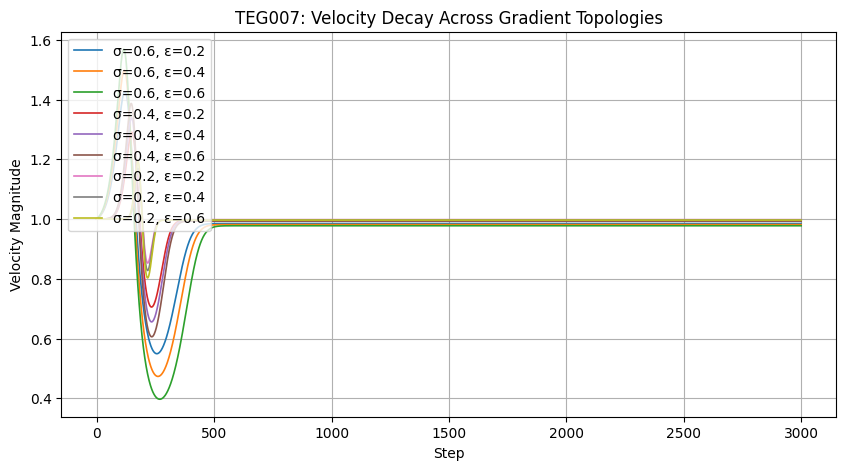

In [1]:
# 🧬 TEG007: Gradient Topology Mapping
# Scans curvature field topology and tracks velocity decay across entropic gradients
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor (Parameterized)
def curvature_tensor(x, y, sigma, epsilon):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x**2 / sigma**2) * exp_term * (1 + epsilon)
    Cyy = (1 - y**2 / sigma**2) * exp_term * (1 - epsilon)
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma, epsilon):
    C = curvature_tensor(x, y, sigma, epsilon)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🚀 Simulation Loop with Speed Tracking
def simulate_decay(x0, y0, vx0, vy0, steps, dt, sigma, epsilon):
    x, y = x0, y0
    vx, vy = vx0, vy0
    speed_over_time = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma, epsilon)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        speed_over_time.append(np.linalg.norm([vx, vy]))

    return np.array(speed_over_time)

# 📊 Speed Decay Plot
def plot_speed_decay(speed_over_time, sigma, epsilon):
    plt.plot(speed_over_time, label=f"σ={sigma}, ε={epsilon}", linewidth=1.2)

# 🧪 Run Gradient Scan
x0, y0 = -2.0, 0.0
vx0, vy0 = 1.0, 0.0
steps = 3000
dt = 0.01

plt.figure(figsize=(10, 5))
plt.title("TEG007: Velocity Decay Across Gradient Topologies")
plt.xlabel("Step")
plt.ylabel("Velocity Magnitude")

# 🔬 Scan curvature parameters
sigmas = [0.6, 0.4, 0.2]
epsilons = [0.2, 0.4, 0.6]

for sigma in sigmas:
    for epsilon in epsilons:
        speed = simulate_decay(x0, y0, vx0, vy0, steps, dt, sigma, epsilon)
        plot_speed_decay(speed, sigma, epsilon)

plt.legend()
plt.grid(True)
plt.show()
